# Assignment 3: Classification Models and Evaluation Metrics

## Course
MBAI 5310G - AI Programming

## Assignment
Assignment 3: Classification Models and Evaluation Metrics

## Student Name and ID
Prabaseelan Vettivelu - 101018683

## Step 2: Business Problem and Dataset Overview

In this notebook, we use a business account upgrade prediction dataset named `business_account_upgrade_prediction_dataset.xls`.

The main business problem is to predict whether a business account will upgrade its account or not based on the information available in the dataset.

The target variable is `Upgraded_Account`, which has two possible values: `Yes` and `No`. Therefore, this is a supervised binary classification problem.

This type of prediction is useful in business analytics because companies want to identify which business customers are more likely to upgrade. The company can use this information to improve sales follow-up, customer support, training decisions, and marketing strategies.

### Business Question

Can we predict whether a business account will upgrade its account using company information, account activity, product usage, and customer engagement features?

### Goal of This Notebook

The goal of this notebook is to train and compare two classification models:

1. Logistic Regression
2. Support Vector Machine (SVM)

For both models, we will calculate:

- Confusion matrix
- Accuracy
- Precision
- Recall
- F1-score

At the end of the notebook, we will compare both models and interpret the results from a business and responsible AI perspective.
Cell 3 — Markdown Cell
## Step 3: Loading the Dataset

In this step, we load the dataset into Python so that we can inspect, clean, and prepare it for machine learning.

The dataset file used in this notebook is named `business_account_upgrade_prediction_dataset.xls`.

Although the file has an `.xls` extension, the data is comma-separated. Therefore, we use `pd.read_csv()` to load the dataset instead of `pd.read_excel()`.

Important: Before running the code, make sure the dataset file is saved in the same folder as this notebook.

In [70]:
# Import pandas library to work with datasets
import pandas as pd

# Import display function to show tables clearly in Jupyter Notebook
from IPython.display import display

# Store the dataset file name in a variable
# Important: Keep the dataset file in the same folder as this notebook
file_path = r"C:\Users\Praba\OneDrive\Desktop\business_account_upgrade_prediction_dataset.xls"

# Read the file and load it into a pandas DataFrame
# Although the file extension is .xls, the data is comma-separated, so read_csv is used
df = pd.read_csv(file_path)

# Print a message to confirm that the dataset has been loaded successfully
print("Dataset loaded successfully!")

# Print the number of rows and columns in the dataset
print("Dataset shape:", df.shape)

# Display the first five rows of the dataset
display(df.head())

Dataset loaded successfully!
Dataset shape: (377, 13)


,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


## Step 4: Initial Data Inspection

After loading the dataset, we inspect it carefully before cleaning and modeling.

Initial data inspection helps us understand the structure, size, columns, data types, missing values, duplicate rows, summary statistics, and target variable distribution.

This step is important because classification models require clean, complete, and well-structured data.

In [8]:
# Display the first five rows of the dataset
display(df.head())

,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


In [9]:
# Display the last five rows of the dataset
display(df.tail())

,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
372,314,Large,Education,4054009.0,125,Basic,99,6,No,56.0,3005,No,No
373,261,Small,Finance,5943853.0,190,Business,116,10,Yes,58.0,172,No,No
374,272,Small,Technology,6513840.0,301,Standard,92,9,Yes,69.0,983,Yes,Yes
375,222,Enterprise,Technology,2754584.0,409,Standard,85,5,Yes,95.0,504,No,Yes
376,49,Small,Technology,7512369.0,176,Basic,101,4,Yes,55.0,279,No,No


In [10]:
# Show the number of rows and columns
print("Number of rows and columns:")
print(df.shape)

Number of rows and columns:
(377, 13)


In [11]:
# Display the column names in the dataset
print("Column names:")
print(df.columns.tolist())

Column names:
['Account_ID', 'Company_Size', 'Industry', 'Annual_Revenue', 'Monthly_Transactions', 'Current_Plan', 'Account_Age_Months', 'Support_Tickets', 'Sales_Contacted', 'Product_Usage_Score', 'Monthly_Fee', 'Training_Attended', 'Upgraded_Account']


In [12]:
# Show general information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Account_ID            377 non-null    int64  
 1   Company_Size          370 non-null    str    
 2   Industry              370 non-null    str    
 3   Annual_Revenue        370 non-null    float64
 4   Monthly_Transactions  377 non-null    int64  
 5   Current_Plan          370 non-null    str    
 6   Account_Age_Months    377 non-null    int64  
 7   Support_Tickets       377 non-null    int64  
 8   Sales_Contacted       370 non-null    str    
 9   Product_Usage_Score   370 non-null    float64
 10  Monthly_Fee           377 non-null    int64  
 11  Training_Attended     377 non-null    str    
 12  Upgraded_Account      377 non-null    str    
dtypes: float64(2), int64(5), str(6)
memory usage: 49.1 KB


In [13]:
# Show summary statistics for numerical columns
display(df.describe())

,Account_ID,Annual_Revenue,Monthly_Transactions,Account_Age_Months,Support_Tickets,Product_Usage_Score,Monthly_Fee
count,377.000000,3.700000e+02,377.000000,377.000000,377.000000,370.000000,377.000000
mean,186.265252,4.060962e+06,248.880637,60.962865,6.933687,51.102703,2408.000000
std,106.726653,2.315737e+06,140.723205,35.513763,4.266190,28.988835,1430.944912
min,1.000000,8.265600e+04,0.000000,1.000000,0.000000,0.000000,83.000000
25%,94.000000,1.902595e+06,130.000000,30.000000,4.000000,27.000000,1231.000000
50%,187.000000,4.182715e+06,248.000000,62.000000,7.000000,51.500000,2414.000000
75%,278.000000,6.017136e+06,363.000000,93.000000,10.000000,76.000000,3623.000000
max,370.000000,7.987036e+06,499.000000,119.000000,14.000000,100.000000,4999.000000


In [14]:
# Check missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Account_ID              0
Company_Size            7
Industry                7
Annual_Revenue          7
Monthly_Transactions    0
Current_Plan            7
Account_Age_Months      0
Support_Tickets         0
Sales_Contacted         7
Product_Usage_Score     7
Monthly_Fee             0
Training_Attended       0
Upgraded_Account        0
dtype: int64


In [15]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 7


In [16]:
# Check the distribution of the target variable
print("Target variable distribution:")
print(df["Upgraded_Account"].value_counts())

Target variable distribution:
Upgraded_Account
No     293
Yes     84
Name: count, dtype: int64


## Step 5: Understanding Features and Target Variable

In this step, we identify the input features and the target variable of the dataset.

The target variable is the column that we want the machine learning models to predict.

In this dataset, the target variable is `Upgraded_Account`. It shows whether a business account upgraded its account or not.

The possible values of the target variable are:

- `Yes`: the business account upgraded
- `No`: the business account did not upgrade

Because the target variable has two possible categories, this is a supervised binary classification problem.

The features are the input columns that help the models make predictions. These features include business account information, account activity, product usage, sales contact status, and training-related information.

At this stage, we identify the possible feature columns and check which columns are numerical and categorical. The final `X` and `y` variables will be created after data cleaning and missing value handling.

In [18]:
# Store the target column name in a variable
target_column = "Upgraded_Account"

# Print the target variable name
print("Target variable:")
print(target_column)

Target variable:
Upgraded_Account


In [20]:
# Print the unique values in the target column
print("Target variable values:")
print("-" * 50)
print(df[target_column].unique())

Target variable values:
--------------------------------------------------
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [21]:
# Count how many accounts are in each target class
target_counts = df[target_column].value_counts()

# Display the target class distribution
print("Target class distribution:")
print("-" * 50)
display(target_counts)

Target class distribution:
--------------------------------------------------


Upgraded_Account
No     293
Yes     84
Name: count, dtype: int64

In [22]:
# Create a list of possible feature columns by removing the target column
feature_columns = df.drop(columns=[target_column]).columns.tolist()

# Print the possible feature columns
print("Possible feature columns:")
print("-" * 50)
print(feature_columns)

Possible feature columns:
--------------------------------------------------
['Account_ID', 'Company_Size', 'Industry', 'Annual_Revenue', 'Monthly_Transactions', 'Current_Plan', 'Account_Age_Months', 'Support_Tickets', 'Sales_Contacted', 'Product_Usage_Score', 'Monthly_Fee', 'Training_Attended']


In [23]:
# Select numerical columns from the dataset
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Select categorical columns from the dataset
categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

# Remove the target column from categorical columns because it is not an input feature
if target_column in categorical_columns:
    categorical_columns.remove(target_column)

# Print numerical columns
print("Numerical feature columns:")
print(numerical_columns)

print("-" * 50)

# Print categorical columns
print("Categorical feature columns:")
print(categorical_columns)

Numerical feature columns:
['Account_ID', 'Annual_Revenue', 'Monthly_Transactions', 'Account_Age_Months', 'Support_Tickets', 'Product_Usage_Score', 'Monthly_Fee']
--------------------------------------------------
Categorical feature columns:
['Company_Size', 'Industry', 'Current_Plan', 'Sales_Contacted', 'Training_Attended']


### Short Interpretation

The target variable is `Upgraded_Account`, which means the models will try to predict whether a business account upgraded or not.

The remaining columns are possible input features. These features describe company characteristics, account activity, product usage, sales contact status, and training-related information.

The column `Account_ID` is only an identifier, so it should not be used as a final feature for model training.

Before training the models, we need to clean the dataset, handle missing values, and then define the final `X` and `y` variables.

## Step 6: Data Cleaning

Before training machine learning models, we need to clean the dataset.

In this step, we create a copy of the original dataset and remove duplicate rows.

Duplicate rows can affect model performance because repeated records may give extra weight to the same information.

In [24]:
# Create a copy of the original dataset
df_clean = df.copy()

# Print a message to confirm that the copy was created
print("A copy of the dataset has been created.")

# Show the shape of the original dataset
print("Original dataset shape:", df.shape)

# Show the shape of the copied dataset
print("Copied dataset shape:", df_clean.shape)

A copy of the dataset has been created.
Original dataset shape: (377, 13)
Copied dataset shape: (377, 13)


In [25]:
# Count the number of duplicate rows before cleaning
duplicates_before = df_clean.duplicated().sum()

# Print the number of duplicate rows before cleaning
print("Number of duplicate rows before cleaning:", duplicates_before)

Number of duplicate rows before cleaning: 7


In [26]:
# Remove duplicate rows from the dataset
df_clean = df_clean.drop_duplicates()

# Print a message to confirm that duplicate rows were removed
print("Duplicate rows have been removed.")

Duplicate rows have been removed.


In [27]:
# Show the shape of the dataset after removing duplicate rows
print("Dataset shape after removing duplicates:", df_clean.shape)

# Count the number of duplicate rows after cleaning
duplicates_after = df_clean.duplicated().sum()

# Print the number of duplicate rows after cleaning
print("Number of duplicate rows after cleaning:", duplicates_after)

Dataset shape after removing duplicates: (370, 13)
Number of duplicate rows after cleaning: 0


In [28]:
# Display the first five rows of the cleaned dataset
display(df_clean.head())

,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


## Step 7: Handling Missing Values

In this step, we handle missing values in the cleaned dataset.

Missing values can cause errors during model training because most machine learning algorithms cannot work with empty cells.

For numerical feature columns, missing values are filled using the median value of each column.

For categorical feature columns, missing values are filled using the most frequent value, also called the mode.

The target variable, `Upgraded_Account`, should not be filled using median or mode. If the target variable has missing values, those rows should be removed because the model needs a known answer to learn from the data.

In [30]:
# Print a title for this output
print("Missing Values Before Handling")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values in each column before handling them
missing_values_before = df_clean.isnull().sum()

# Display missing values before handling
display(missing_values_before)

Missing Values Before Handling
--------------------------------------------------


Account_ID              0
Company_Size            7
Industry                7
Annual_Revenue          7
Monthly_Transactions    0
Current_Plan            7
Account_Age_Months      0
Support_Tickets         0
Sales_Contacted         7
Product_Usage_Score     7
Monthly_Fee             0
Training_Attended       0
Upgraded_Account        0
dtype: int64

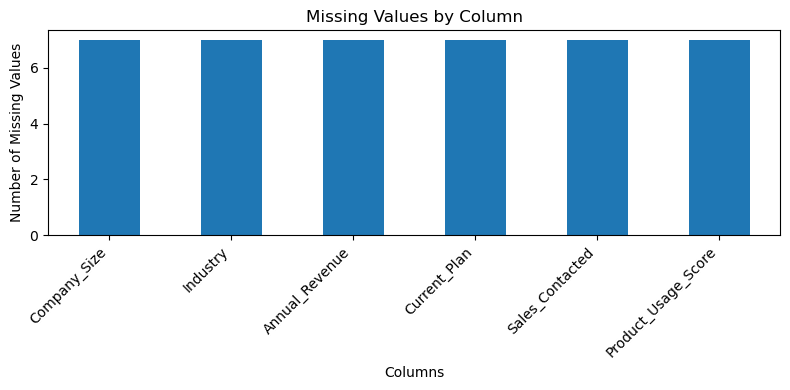

In [31]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Select only columns that have missing values
missing_columns = missing_values_before[missing_values_before > 0]

# Check whether there are missing values before creating the chart
if len(missing_columns) > 0:
    
    # Create a figure for the missing values chart
    plt.figure(figsize=(8, 4))
    
    # Create a bar chart for columns with missing values
    missing_columns.plot(kind="bar")
    
    # Add a title to the chart
    plt.title("Missing Values by Column")
    
    # Add a label to the x-axis
    plt.xlabel("Columns")
    
    # Add a label to the y-axis
    plt.ylabel("Number of Missing Values")
    
    # Rotate x-axis labels to make them easier to read
    plt.xticks(rotation=45, ha="right")
    
    # Adjust the layout so labels do not overlap
    plt.tight_layout()
    
    # Display the chart
    plt.show()

else:
    print("There are no missing values to display in a chart.")

In [32]:
# Check whether the target variable has missing values
missing_target_values = df_clean[target_column].isnull().sum()

print("Missing values in target variable:", missing_target_values)

Missing values in target variable: 0


In [33]:
# Remove rows where the target variable is missing, if any
df_clean = df_clean.dropna(subset=[target_column])

# Print the dataset shape after checking the target variable
print("Dataset shape after checking target missing values:", df_clean.shape)

Dataset shape after checking target missing values: (370, 13)


In [34]:
# Define columns that should not be filled as normal features
columns_to_exclude = ["Account_ID", target_column]

# Create a feature-only dataset for identifying numerical and categorical feature columns
feature_data_for_missing = df_clean.drop(columns=columns_to_exclude, errors="ignore")

# Select numerical feature columns from the cleaned dataset
numerical_columns = feature_data_for_missing.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Select categorical feature columns from the cleaned dataset
categorical_columns = feature_data_for_missing.select_dtypes(include=["object", "string", "category"]).columns.tolist()

# Print numerical columns
print("Numerical feature columns:")
print(numerical_columns)

print("-" * 50)

# Print categorical columns
print("Categorical feature columns:")
print(categorical_columns)

Numerical feature columns:
['Annual_Revenue', 'Monthly_Transactions', 'Account_Age_Months', 'Support_Tickets', 'Product_Usage_Score', 'Monthly_Fee']
--------------------------------------------------
Categorical feature columns:
['Company_Size', 'Industry', 'Current_Plan', 'Sales_Contacted', 'Training_Attended']


In [35]:
# Loop through each numerical feature column
for column in numerical_columns:
    
    # Calculate the median value of the current numerical column
    median_value = df_clean[column].median()
    
    # Fill missing values in the current column with the median value
    df_clean[column] = df_clean[column].fillna(median_value)

# Print a message after handling numerical missing values
print("Missing values in numerical feature columns have been filled with the median.")

Missing values in numerical feature columns have been filled with the median.


In [36]:
# Loop through each categorical feature column
for column in categorical_columns:
    
    # Calculate the most frequent value of the current categorical column
    mode_value = df_clean[column].mode()[0]
    
    # Fill missing values in the current column with the most frequent value
    df_clean[column] = df_clean[column].fillna(mode_value)

# Print a message after handling categorical missing values
print("Missing values in categorical feature columns have been filled with the mode.")

Missing values in categorical feature columns have been filled with the mode.


In [37]:
# Print a title for this output
print("Missing Values After Handling")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values after handling them
missing_values_after = df_clean.isnull().sum()

# Display missing values after handling
display(missing_values_after)

Missing Values After Handling
--------------------------------------------------


Account_ID              0
Company_Size            0
Industry                0
Annual_Revenue          0
Monthly_Transactions    0
Current_Plan            0
Account_Age_Months      0
Support_Tickets         0
Sales_Contacted         0
Product_Usage_Score     0
Monthly_Fee             0
Training_Attended       0
Upgraded_Account        0
dtype: int64

In [38]:
# Print the shape of the cleaned dataset after handling missing values
print("Dataset shape after handling missing values:", df_clean.shape)

# Display the first five rows of the cleaned dataset
display(df_clean.head())

Dataset shape after handling missing values: (370, 13)


,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


### Short Interpretation

The missing values have now been handled.

Numerical missing values were replaced with the median, and categorical missing values were replaced with the most frequent value.

The target variable was checked separately because it should not be filled like a normal feature column.

Now the dataset is more complete and ready for the next step: handling categorical and numerical variables.

## Step 8: Handling Categorical and Numerical Variables

In this step, we identify numerical and categorical variables in the cleaned dataset.

Numerical variables contain numbers, such as annual revenue, monthly transactions, account age, support tickets, product usage score, and monthly fee.

Categorical variables contain groups or labels, such as company size, industry, current plan, sales contacted, and training attended.

This step is important because machine learning models need numerical input.

Later, categorical variables will be converted into numerical format during preprocessing using one-hot encoding.

The columns `Account_ID` and `Upgraded_Account` are excluded from the feature list. `Account_ID` is only an identifier, and `Upgraded_Account` is the target variable.

In [39]:
# Define the target column name
target_column = "Upgraded_Account"

# Print the target column name
print("Target column:")
print(target_column)

Target column:
Upgraded_Account


In [40]:
# Create a feature-only dataset by removing Account_ID and the target column
feature_data = df_clean.drop(columns=["Account_ID", target_column])

# Select numerical feature columns from the feature-only dataset
numerical_features = feature_data.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Print a title for numerical features
print("Numerical feature columns:")
print("-" * 50)

# Display numerical feature columns
print(numerical_features)

Numerical feature columns:
--------------------------------------------------
['Annual_Revenue', 'Monthly_Transactions', 'Account_Age_Months', 'Support_Tickets', 'Product_Usage_Score', 'Monthly_Fee']


In [41]:
# Select categorical feature columns from the feature-only dataset
categorical_features = feature_data.select_dtypes(include=["object", "string", "category"]).columns.tolist()

# Print a title for categorical features
print("Categorical feature columns:")
print("-" * 50)

# Display categorical feature columns
print(categorical_features)

Categorical feature columns:
--------------------------------------------------
['Company_Size', 'Industry', 'Current_Plan', 'Sales_Contacted', 'Training_Attended']


In [42]:
# Count the number of numerical features
num_count = len(numerical_features)

# Count the number of categorical features
cat_count = len(categorical_features)

# Print the number of numerical features
print("Number of numerical features:", num_count)

# Print the number of categorical features
print("Number of categorical features:", cat_count)

Number of numerical features: 6
Number of categorical features: 5


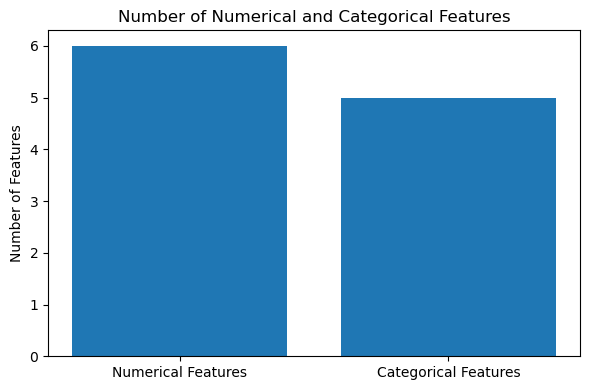

In [43]:
# Create labels for the chart
feature_type_labels = ["Numerical Features", "Categorical Features"]

# Create values for the chart
feature_type_counts = [num_count, cat_count]

# Create a figure for the chart
plt.figure(figsize=(6, 4))

# Create a bar chart
plt.bar(feature_type_labels, feature_type_counts)

# Add a chart title
plt.title("Number of Numerical and Categorical Features")

# Add a label to the y-axis
plt.ylabel("Number of Features")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [44]:
# Print a title for unique values
print("Unique values in categorical features")
print("-" * 50)

# Loop through each categorical feature
for column in categorical_features:
    
    # Print the column name
    print("Column:", column)
    
    # Print the unique values in the column
    print(df_clean[column].unique())
    
    # Print a separator line
    print("-" * 50)

Unique values in categorical features
--------------------------------------------------
Column: Company_Size
<ArrowStringArray>
['Small', 'Enterprise', 'Large', 'Medium']
Length: 4, dtype: str
--------------------------------------------------
Column: Industry
<ArrowStringArray>
['Healthcare', 'Manufacturing', 'Education', 'Finance', 'Technology',
 'Retail']
Length: 6, dtype: str
--------------------------------------------------
Column: Current_Plan
<ArrowStringArray>
['Business', 'Basic', 'Premium', 'Standard']
Length: 4, dtype: str
--------------------------------------------------
Column: Sales_Contacted
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
Column: Training_Attended
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------


In [45]:
# Count unique values for each categorical feature
categorical_unique_counts = df_clean[categorical_features].nunique()

# Print a title
print("Number of unique values in each categorical feature:")
print("-" * 50)

# Display the number of unique values
display(categorical_unique_counts)

Number of unique values in each categorical feature:
--------------------------------------------------


Company_Size         4
Industry             6
Current_Plan         4
Sales_Contacted      2
Training_Attended    2
dtype: int64

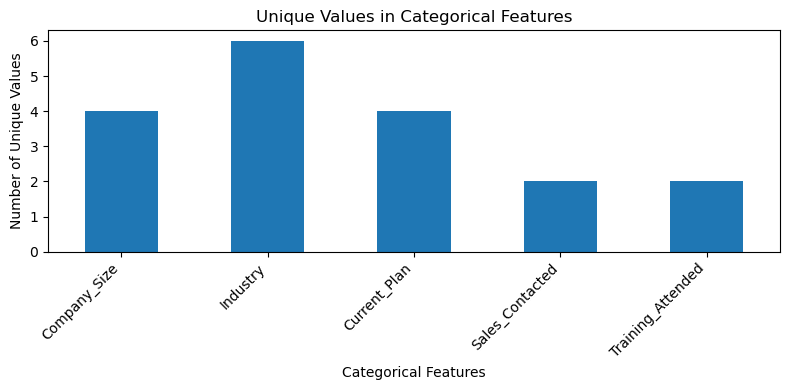

In [46]:
# Create a figure for the categorical unique values chart
plt.figure(figsize=(8, 4))

# Create a bar chart for unique values in categorical columns
categorical_unique_counts.plot(kind="bar")

# Add a chart title
plt.title("Unique Values in Categorical Features")

# Add a label to the x-axis
plt.xlabel("Categorical Features")

# Add a label to the y-axis
plt.ylabel("Number of Unique Values")

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

### Short Interpretation

The dataset contains both numerical and categorical features.

Numerical features can be used by the models after scaling, while categorical features must be converted into numerical format before training.

In this project, categorical features will be converted using one-hot encoding during preprocessing.

The next step is to define `X` and `y`, where `X` contains the feature variables and `y` contains the target variable, `Upgraded_Account`.

## Step 9: Define X and y

In this step, we separate the cleaned dataset into feature variables and the target variable.

The target variable is `Upgraded_Account`. This is the variable that the models are trying to predict.

The feature variables are the input columns that the models will use to make predictions.

The `Account_ID` column is removed because it is only an identification number. It does not provide meaningful information for predicting whether an account will upgrade.

Therefore:

- `X` = feature variables used to make predictions
- `y` = target variable, `Upgraded_Account`

After this step, `X` will contain the input columns, and `y` will contain the answer column that the models need to learn from.

In [47]:
# Define the target variable
target = "Upgraded_Account"

# Define X by removing the target column and Account_ID from the cleaned dataset
X = df_clean.drop(columns=[target, "Account_ID"])

# Define y as the target variable from the cleaned dataset
y = df_clean[target]

# Display the shape of X and y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Display selected feature columns
print("\nFeature columns:")
print(X.columns.tolist())

# Display target variable name
print("\nTarget variable:")
print(target)

Shape of X: (370, 11)
Shape of y: (370,)

Feature columns:
['Company_Size', 'Industry', 'Annual_Revenue', 'Monthly_Transactions', 'Current_Plan', 'Account_Age_Months', 'Support_Tickets', 'Sales_Contacted', 'Product_Usage_Score', 'Monthly_Fee', 'Training_Attended']

Target variable:
Upgraded_Account


In [48]:
# Show the first five rows of X
display(X.head())

,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended
0,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes
1,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes
2,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No
3,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No
4,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes


In [49]:
# Show the first five rows of X
display(X.head())

,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended
0,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes
1,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes
2,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No
3,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No
4,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes


## Step 10: Train/Test Split

The dataset is split into training and testing sets.

The training set is used to train the models. The testing set is kept separate and used to evaluate the models on unseen data.

This helps us check whether the models can generalize to new business accounts.

I used:

- 80% of the data for training
- 20% of the data for testing
- `random_state=42` to make the split reproducible
- `stratify=y` to keep the Yes/No target balance similar in both training and testing sets

In [50]:
# Import train_test_split to split the dataset
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shape of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (296, 11)
X_test shape: (74, 11)
y_train shape: (296,)
y_test shape: (74,)


In [51]:
# Check the target distribution in training data
print("Training target distribution:")
print(y_train.value_counts())

print("-" * 50)

# Check the target distribution in testing data
print("Testing target distribution:")
print(y_test.value_counts())

Training target distribution:
Upgraded_Account
No     230
Yes     66
Name: count, dtype: int64
--------------------------------------------------
Testing target distribution:
Upgraded_Account
No     58
Yes    16
Name: count, dtype: int64


## Step 11: Preprocessing

Preprocessing prepares the data for machine learning models.

For numerical variables:

- Values are scaled using StandardScaler

For categorical variables:

- Categories are converted into numerical format using OneHotEncoder

This preprocessing step is especially important because SVM is sensitive to feature scale. Scaling helps prevent larger numerical values from dominating smaller numerical values.

Since missing values were already handled in the previous step, this preprocessing step focuses on scaling numerical features and encoding categorical features.

In [52]:
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Create preprocessing steps for numerical columns
numerical_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Create preprocessing steps for categorical columns
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## Step 12: Model 1 - Logistic Regression

The first classification model used in this assignment is Logistic Regression.

Logistic Regression is a common baseline model for binary classification problems. It is useful because it is simple, easy to interpret, and suitable when the target variable has two classes.

In this project, Logistic Regression will predict whether a business account will upgrade or not.

In [53]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression pipeline
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the Logistic Regression model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## Step 13: Model 2 - Support Vector Machine (SVM)

The second classification model used in this assignment is Support Vector Machine, also called SVM.

SVM is a classification model that tries to separate classes using a decision boundary. It can work well for classification problems, especially when proper preprocessing and scaling are applied.

In this project, SVM will also predict whether a business account will upgrade or not.

In [54]:
# Import SVM classifier
from sklearn.svm import SVC

# Create the SVM pipeline
svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf", random_state=42))
])

# Train the SVM model
svm_model.fit(X_train, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


## Step 14: Model Prediction

After training both models, we use the testing data to make predictions.

The testing data was not used during training, so it helps evaluate how well each model performs on unseen business account records.

In [55]:
# Make predictions using Logistic Regression
y_pred_logistic = logistic_model.predict(X_test)

# Make predictions using SVM
y_pred_svm = svm_model.predict(X_test)

# Display the first ten predictions from both models
print("First 10 Logistic Regression predictions:")
print(y_pred_logistic[:10])

print("-" * 50)

print("First 10 SVM predictions:")
print(y_pred_svm[:10])

First 10 Logistic Regression predictions:
['No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No']
--------------------------------------------------
First 10 SVM predictions:
['No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No']


## Step 15: Model Evaluation

In this step, we evaluate both classification models using the required evaluation metrics.

The required metrics are:

1. Confusion matrix
2. Accuracy
3. Precision
4. Recall
5. F1-score

Accuracy shows the overall percentage of correct predictions.

Precision shows how many predicted `Yes` upgrade cases were actually correct.

Recall shows how many actual `Yes` upgrade cases the model successfully identified.

F1-score balances precision and recall into one metric.

In [58]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Create a function to evaluate classification models
def evaluate_model(model_name, y_true, y_pred):
    """
    This function calculates and displays evaluation metrics for a classification model.
    """
    
    # Calculate evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label="Yes", zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label="Yes", zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label="Yes", zero_division=0)
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=["No", "Yes"])
    
    # Convert confusion matrix to a DataFrame for clear display
    cm_df = pd.DataFrame(
        cm,
        index=["Actual No", "Actual Yes"],
        columns=["Predicted No", "Predicted Yes"]
    )
    
    # Print model name
    print(model_name)
    print("=" * 50)
    
    # Display confusion matrix
    print("Confusion Matrix:")
    display(cm_df)
    
    # Print metrics
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-score:", round(f1, 4))
    
    print("-" * 50)
    print("Classification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    # Return metrics as a dictionary
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

In [59]:
# Evaluate Logistic Regression
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_logistic
)

Logistic Regression
Confusion Matrix:


,Predicted No,Predicted Yes
Actual No,51,7
Actual Yes,11,5


Accuracy: 0.7568
Precision: 0.4167
Recall: 0.3125
F1-score: 0.3571
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.88      0.85        58
         Yes       0.42      0.31      0.36        16

    accuracy                           0.76        74
   macro avg       0.62      0.60      0.60        74
weighted avg       0.73      0.76      0.74        74



In [60]:
# Evaluate SVM
svm_results = evaluate_model(
    "SVM",
    y_test,
    y_pred_svm
)

SVM
Confusion Matrix:


,Predicted No,Predicted Yes
Actual No,56,2
Actual Yes,11,5


Accuracy: 0.8243
Precision: 0.7143
Recall: 0.3125
F1-score: 0.4348
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.97      0.90        58
         Yes       0.71      0.31      0.43        16

    accuracy                           0.82        74
   macro avg       0.78      0.64      0.67        74
weighted avg       0.81      0.82      0.80        74



## Step 16: Model Comparison

In this step, we compare the results of Logistic Regression and SVM.

The comparison focuses on accuracy, precision, recall, and F1-score.

This helps us decide which model performed better for the business account upgrade prediction problem.

In [61]:
# Create a comparison table for both models
comparison_df = pd.DataFrame([logistic_results, svm_results])

# Round the metric values for cleaner display
comparison_df[["Accuracy", "Precision", "Recall", "F1-score"]] = comparison_df[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].round(4)

# Display the comparison table
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.7568,0.4167,0.3125,0.3571
1,SVM,0.8243,0.7143,0.3125,0.4348


In [62]:
# Identify the best model based on accuracy
best_model_accuracy = comparison_df.loc[comparison_df["Accuracy"].idxmax(), "Model"]

# Identify the best model based on F1-score
best_model_f1 = comparison_df.loc[comparison_df["F1-score"].idxmax(), "Model"]

print("Best model based on accuracy:", best_model_accuracy)
print("Best model based on F1-score:", best_model_f1)

Best model based on accuracy: SVM
Best model based on F1-score: SVM


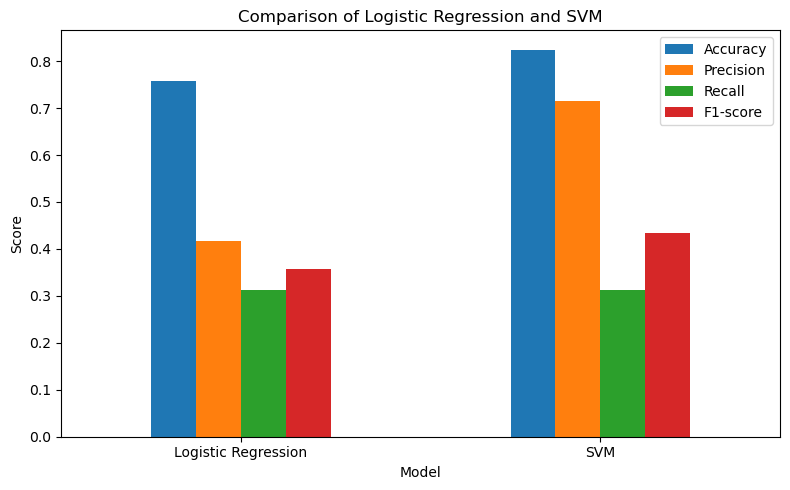

In [63]:
# Create a bar chart to compare the models
comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(8, 5)
)

# Add chart title
plt.title("Comparison of Logistic Regression and SVM")

# Add y-axis label
plt.ylabel("Score")

# Rotate x-axis labels
plt.xticks(rotation=0)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

## Step 17: Business Interpretation and Task 2 Answers

### Which model performed better?

Based on the comparison table, SVM performed better overall in this run because it achieved higher accuracy, precision, and F1-score than Logistic Regression.

Logistic Regression achieved an accuracy of approximately 75.68%, while SVM achieved an accuracy of approximately 82.43%.

SVM also had higher precision and F1-score. However, both models had the same recall for the `Yes` class, which means both models identified the same proportion of actual upgrade accounts.

Therefore, SVM performed better overall, but both models still have room for improvement in identifying actual upgrade customers.

### Which metric is most important for the business problem?

For this business problem, recall for the `Yes` class is very important because the company wants to identify accounts that are likely to upgrade.

A false negative means the model misses an account that actually upgraded. This could be a missed business opportunity.

However, precision is also important because sales and marketing resources are limited. If precision is low, the company may spend time contacting accounts that are not actually likely to upgrade.

Therefore, F1-score is useful because it balances precision and recall. In this notebook, SVM has the better F1-score, so it is the stronger model overall.

### What do false positives and false negatives mean in this dataset?

A false positive means the model predicts that a business account will upgrade, but the account does not actually upgrade.

In business terms, this may cause the company to spend sales or marketing resources on an account that is not truly likely to upgrade.

A false negative means the model predicts that a business account will not upgrade, but the account actually upgrades.

In business terms, this is a missed opportunity because the company may fail to identify and support a real potential upgrade customer.

### What is one possible limitation or bias in the model?

One possible limitation is class imbalance. If the dataset has more `No` upgrade cases than `Yes` upgrade cases, the models may become better at predicting accounts that do not upgrade and weaker at identifying accounts that actually upgrade.

Another limitation is that the dataset may not include all important business factors, such as customer satisfaction, competitor offers, contract renewal timing, or detailed sales interaction history.

### Why should human judgment still be used?

Human judgment should still be used because machine learning models can make incorrect predictions.

The model should support business decisions, not replace them completely. Sales teams and managers should review model predictions together with customer context, business knowledge, and professional judgment before making important decisions.

## Step 18: Responsible AI Reflection

This model should be used as a decision-support tool, not as the only basis for business decisions.

The model predicts whether a business account is likely to upgrade, but it may still make mistakes. Some accounts predicted as unlikely to upgrade may actually upgrade later, and some accounts predicted as likely to upgrade may not upgrade.

The company should not use the model to unfairly ignore or exclude customers. Human review is still important, especially when making sales, support, pricing, or customer relationship decisions.

A responsible AI concern is class imbalance. If the dataset contains more `No` cases than `Yes` cases, the model may perform better for the majority class and may be weaker at identifying upgrade customers.

Another concern is data quality. If the dataset contains missing values, outdated information, or limited business variables, the predictions may not fully reflect real customer behaviour.

Therefore, before using this model in a real business setting, the company should test it further, monitor its performance, check for bias, and make sure the predictions are used fairly and responsibly.

## Step 19: GitHub Submission Note

For submission, I will upload the completed Jupyter Notebook and dataset to my GitHub repository.

The repository should include:

- The completed notebook
- The dataset file
- A README file explaining the project
- The GitHub repository link submitted on Canvas

The notebook should run from top to bottom without errors.